In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Robert\Desktop\projeto_01\data\stg\stg_moedas_silver.csv")

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# === FUNÇÃO AUTOMATIZADA DE ANÁLISE ===
def analisar_dupla_moedas(dataframe, moeda_1, moeda_2):
    """
    Gera o gráfico de eixo duplo e calcula a correlação de Pearson
    para quaisquer duas moedas informadas.
    """
    # 1. Preparação e filtragem dos dados (Garantindo o tipo de data)
    df_temp = dataframe.copy()
    df_temp["data"] = pd.to_datetime(df_temp["data"])
    
    df_m1 = df_temp[df_temp["moeda"] == moeda_1].sort_values(by="data")
    df_m2 = df_temp[df_temp["moeda"] == moeda_2].sort_values(by="data")
    
    # Validação caso digite o código errado
    if df_m1.empty or df_m2.empty:
        print(f"⚠️ Erro: Verifique os códigos. {moeda_1} ou {moeda_2} não encontrados.")
        return

    nome_m1 = df_m1["name"].iloc[0]
    nome_m2 = df_m2["name"].iloc[0]

    # 2. Cálculo da Correlação de Pearson
    serie_m1 = df_m1.set_index("data")["bid"]
    serie_m2 = df_m2.set_index("data")["bid"]
    indice_pearson = serie_m1.corr(serie_m2, method="pearson")

    # 3. Construção do Gráfico Duplo
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Desenha a Moeda 1 (Eixo Esquerdo)
    color_m1 = "darkred"
    ax1.plot(df_m1["data"], df_m1["bid"], color=color_m1, linewidth=2.5, label=f"{moeda_1} (Esq.)")
    ax1.set_xlabel("Data (Amostragem Semestral)", fontsize=13)
    ax1.set_ylabel(f"Preço: {nome_m1}", color=color_m1, fontsize=13)
    ax1.tick_params(axis='y', labelcolor=color_m1)

    # Cria o eixo gêmeo para a Moeda 2 (Eixo Direito)
    ax2 = ax1.twinx()
    color_m2 = "darkgreen"
    ax2.plot(df_m2["data"], df_m2["bid"], color=color_m2, linewidth=2, linestyle="--", label=f"{moeda_2} (Dir.)")
    ax2.set_ylabel(f"Preço: {nome_m2}", color=color_m2, fontsize=13)
    ax2.tick_params(axis='y', labelcolor=color_m2)

    # Ajuste das datas no eixo X
    fmt_half_year = mdates.MonthLocator(interval=6)
    ax1.xaxis.set_major_locator(fmt_half_year)
    fmt_date = mdates.DateFormatter("%Y-%m")
    ax1.xaxis.set_major_formatter(fmt_date)
    fig.autofmt_xdate(rotation=45)

    # Unificar as legendas
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    plt.title(f"Análise Comparativa: {moeda_1} vs {moeda_2} (Pearson: {indice_pearson:.2f})", fontsize=15, fontweight='bold')
    ax1.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    # 4. Salvar o gráfico automaticamente com o nome dinâmico
    nome_arquivo = f"comparativo_{moeda_1.lower()}_vs_{moeda_2.lower()}.png".replace("-", "_")
    plt.savefig(nome_arquivo, dpi=300, bbox_inches="tight")

    # Mostra o gráfico na tela
    plt.show()
    
    print("-" * 50)
    print(f"📊 Resultado: O Índice de Correlação de Pearson é {indice_pearson:.2f}")
    print(f"💾 Gráfico salvo como: {nome_arquivo}")
    print("-" * 50)

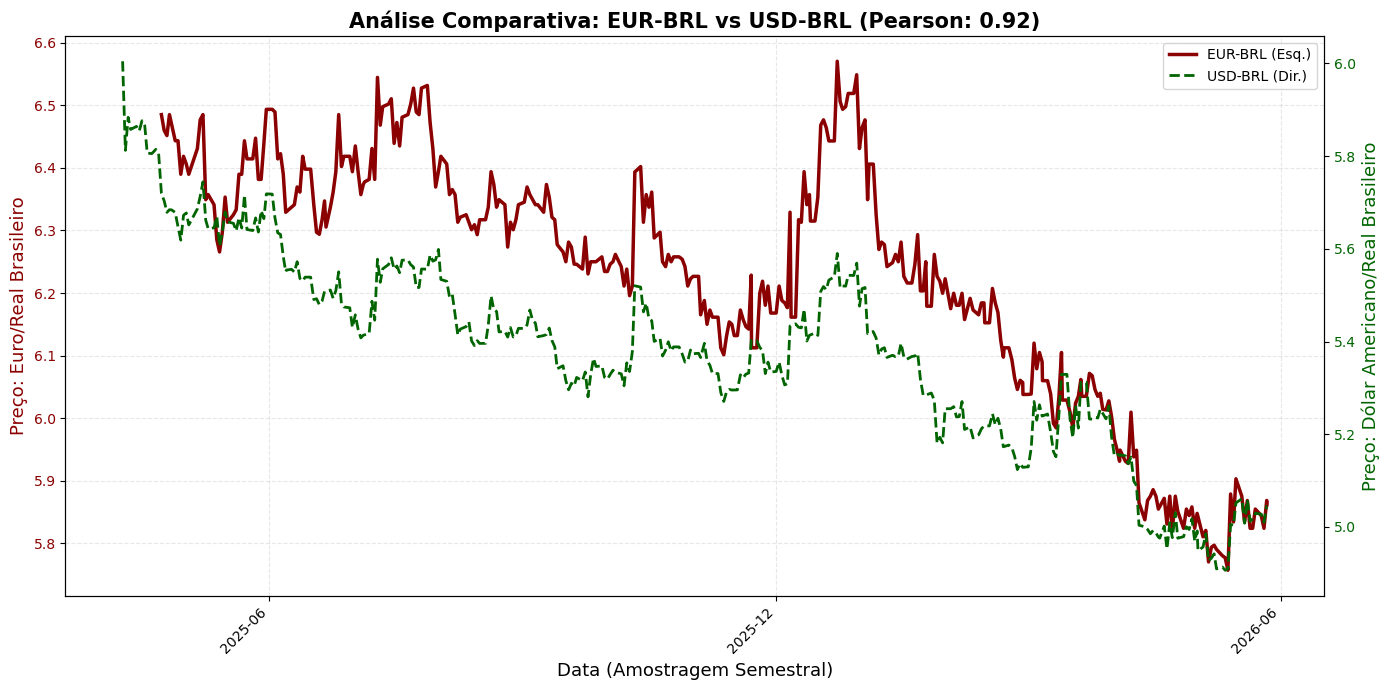

--------------------------------------------------
📊 Resultado: O Índice de Correlação de Pearson é 0.92
💾 Gráfico salvo como: comparativo_eur_brl_vs_usd_brl.png
--------------------------------------------------


In [7]:
analisar_dupla_moedas(df, "EUR-BRL", "USD-BRL")